# Simulator Validation & Demand Modeling
## A Research-Driven Approach to Market Dynamics Capture

**Objective:** Systematically build and validate each component of the markdown pricing simulator:
1. **Demand Models**: Linear Regression → XGBoost → LSTM (step-up complexity)
2. **Customer Choice Model**: MNL with review scores, price sensitivity, quality
3. **Backtesting**: Compare simulated vs actual demand/revenue at segment level
4. **Market Dynamics Verification**: Do we capture substitution, seasonality, price sensitivity?

**Key Question:** How accurately does our simulator reproduce historical market behavior?

In [14]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import train_test_split, TimeSeriesSplit
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler
import xgboost as xgb
import lightgbm as lgb
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import os, pickle

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['figure.dpi'] = 100

DATA_DIR = '/Users/ajit/Documents/Pricing/'

# Load data
orders = pd.read_csv(DATA_DIR + 'olist_orders_dataset.csv')
order_items = pd.read_csv(DATA_DIR + 'olist_order_items_dataset.csv')
products = pd.read_csv(DATA_DIR + 'olist_products_dataset.csv')
customers = pd.read_csv(DATA_DIR + 'olist_customers_dataset.csv')
payments = pd.read_csv(DATA_DIR + 'olist_order_payments_dataset.csv')
reviews = pd.read_csv(DATA_DIR + 'olist_order_reviews_dataset.csv')
category_trans = pd.read_csv(DATA_DIR + 'product_category_name_translation.csv')
segments = pd.read_csv(DATA_DIR + 'product_segments.csv')

# Date parsing
orders['order_purchase_timestamp'] = pd.to_datetime(orders['order_purchase_timestamp'])

# Build master table with segments and reviews
products_en = products.merge(category_trans, on='product_category_name', how='left')
products_en['product_category_name_english'] = products_en['product_category_name_english'].fillna(products_en['product_category_name'])
products_en = products_en.merge(segments[['product_id', 'segment']], on='product_id', how='left')

master = order_items.merge(orders[['order_id', 'order_purchase_timestamp', 'order_status', 'customer_id']], on='order_id')
master = master.merge(products_en[['product_id', 'product_category_name_english', 'segment']], on='product_id', how='left')

# Merge review scores at ORDER level
review_scores = reviews.groupby('order_id')['review_score'].mean().reset_index()
master = master.merge(review_scores, on='order_id', how='left')

# Filter delivered only
master = master[master['order_status'] == 'delivered'].copy()
master['review_score'] = master['review_score'].fillna(master['review_score'].median())

# Temporal features
master['order_date'] = master['order_purchase_timestamp'].dt.date
master['week'] = master['order_purchase_timestamp'].dt.isocalendar().week.astype(int)
master['year'] = master['order_purchase_timestamp'].dt.year
master['month'] = master['order_purchase_timestamp'].dt.month
master['dow'] = master['order_purchase_timestamp'].dt.dayofweek

print(f"Master data: {master.shape}")
print(f"Segments found: {master['segment'].nunique()}")
print(f"Date range: {master['order_purchase_timestamp'].min()} to {master['order_purchase_timestamp'].max()}")
print(f"\nReview score distribution:")
print(master['review_score'].describe())

FileNotFoundError: [Errno 2] No such file or directory: '/Users/ajit/Documents/Pricing/olist_orders_dataset.csv'

## Step 1: Construct Weekly Segment-Level Panel Dataset

Create a proper panel dataset: (segment × week) with demand, average price, review score, and temporal features. This is the foundation for all demand models and simulator calibration.

In [2]:
# Create year-week identifier
master['year_week'] = master['year'].astype(str) + '-W' + master['week'].astype(str).str.zfill(2)

# Build weekly segment-level panel
panel = master.groupby(['segment', 'year_week']).agg(
    quantity=('order_id', 'count'),  # Demand = number of items sold
    avg_price=('price', 'mean'),
    median_price=('price', 'median'),
    price_std=('price', 'std'),
    total_revenue=('price', 'sum'),
    avg_freight=('freight_value', 'mean'),
    avg_review=('review_score', 'mean'),
    num_unique_products=('product_id', 'nunique'),
    num_unique_customers=('customer_id', 'nunique'),
    avg_dow=('dow', 'mean'),  # Weighted day-of-week
).reset_index()

panel['price_std'] = panel['price_std'].fillna(0)

# Parse back year and week for proper ordering
panel['year'] = panel['year_week'].str[:4].astype(int)
panel['week'] = panel['year_week'].str[-2:].astype(int)
panel = panel.sort_values(['segment', 'year', 'week']).reset_index(drop=True)

# Add lag features (previous week's demand, price)
panel['lag1_quantity'] = panel.groupby('segment')['quantity'].shift(1)
panel['lag2_quantity'] = panel.groupby('segment')['quantity'].shift(2)
panel['lag1_price'] = panel.groupby('segment')['avg_price'].shift(1)
panel['lag1_review'] = panel.groupby('segment')['avg_review'].shift(1)

# Rolling averages
panel['rolling4_quantity'] = panel.groupby('segment')['quantity'].transform(
    lambda x: x.rolling(4, min_periods=1).mean()
)

# Log transforms for elasticity
panel['log_quantity'] = np.log1p(panel['quantity'])
panel['log_price'] = np.log1p(panel['avg_price'])

# Create price-to-segment-mean ratio (proxy for "discount" relative to normal price)
segment_mean_price = panel.groupby('segment')['avg_price'].transform('mean')
panel['price_ratio'] = panel['avg_price'] / segment_mean_price
panel['log_price_ratio'] = np.log(panel['price_ratio'])

# Filter to period with sufficient data (2017 onward)
panel = panel[(panel['year'] >= 2017)].copy()
panel = panel.dropna(subset=['lag1_quantity']).reset_index(drop=True)

print(f"Panel shape: {panel.shape}")
print(f"Segments: {panel['segment'].nunique()}")
print(f"Weeks per segment (median): {panel.groupby('segment').size().median():.0f}")
print(f"\nPanel columns: {list(panel.columns)}")
print(f"\nPanel summary:")
print(panel[['quantity', 'avg_price', 'avg_review', 'lag1_quantity', 'price_ratio']].describe())

Panel shape: (1260, 23)
Segments: 15
Weeks per segment (median): 87

Panel columns: ['segment', 'year_week', 'quantity', 'avg_price', 'median_price', 'price_std', 'total_revenue', 'avg_freight', 'avg_review', 'num_unique_products', 'num_unique_customers', 'avg_dow', 'year', 'week', 'lag1_quantity', 'lag2_quantity', 'lag1_price', 'lag1_review', 'rolling4_quantity', 'log_quantity', 'log_price', 'price_ratio', 'log_price_ratio']

Panel summary:
          quantity    avg_price   avg_review  lag1_quantity  price_ratio
count  1260.000000  1260.000000  1260.000000    1260.000000  1260.000000
mean     87.206349   241.748974     3.901994      87.093651     1.000830
std     115.502969   353.181047     1.071903     115.574392     0.292272
min       1.000000     9.517727     1.000000       1.000000     0.067813
25%      20.000000    59.607507     3.666667      20.000000     0.906958
50%      49.000000   136.888203     4.239423      49.000000     0.987532
75%     103.000000   261.423617     4.64638

## Step 2: Demand Model 1 — Linear Regression Baseline

Estimate: $\ln(Q_{s,t}) = \alpha_s + \beta_1 \ln(P_{s,t}) + \beta_2 \cdot \text{review}_{s,t} + \beta_3 \cdot Q_{s,t-1} + \beta_4 \cdot \text{week} + \epsilon$

This gives us interpretable elasticity coefficients and a baseline to beat.

In [3]:
# Prepare features for demand models
# Target: log(quantity) for interpretability (log-log model gives elasticities)
# Features: log(price), review scores, lags, temporal, segment dummies

feature_cols = ['log_price', 'avg_review', 'lag1_quantity', 'lag2_quantity',
                'rolling4_quantity', 'week', 'price_ratio', 'avg_freight',
                'num_unique_products']

# Add segment dummies
segment_dummies = pd.get_dummies(panel['segment'], prefix='seg', dtype=float)
panel_features = pd.concat([panel, segment_dummies], axis=1)

all_features = feature_cols + [c for c in segment_dummies.columns]

# Time-based train/test split (last 20% of weeks for testing)
panel_features = panel_features.sort_values(['year', 'week', 'segment']).reset_index(drop=True)
split_idx = int(len(panel_features) * 0.8)
train = panel_features.iloc[:split_idx].copy()
test = panel_features.iloc[split_idx:].copy()

X_train = train[all_features].fillna(0)
y_train = train['log_quantity']
X_test = test[all_features].fillna(0)
y_test = test['log_quantity']

print(f"Train: {len(train)} obs, Test: {len(test)} obs")
print(f"Features: {len(all_features)}")

# Model 1: Linear Regression (log-log)
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

# Back-transform to original scale for comparison
y_test_actual = np.expm1(y_test)
y_pred_lr_actual = np.expm1(y_pred_lr)

rmse_lr = np.sqrt(mean_squared_error(y_test_actual, y_pred_lr_actual))
mae_lr = mean_absolute_error(y_test_actual, y_pred_lr_actual)
r2_lr = r2_score(y_test, y_pred_lr)  # R² in log space
mape_lr = np.mean(np.abs((y_test_actual - y_pred_lr_actual) / np.maximum(y_test_actual, 1))) * 100

print(f"\n--- Linear Regression Results ---")
print(f"R² (log space): {r2_lr:.4f}")
print(f"RMSE (units): {rmse_lr:.2f}")
print(f"MAE (units): {mae_lr:.2f}")
print(f"MAPE: {mape_lr:.1f}%")

# Interpret key coefficients
print(f"\n--- Key Coefficients (Interpretable as Elasticities) ---")
coef_df = pd.DataFrame({'feature': all_features, 'coefficient': lr.coef_})
for feat in ['log_price', 'avg_review', 'lag1_quantity', 'price_ratio', 'avg_freight']:
    coef = coef_df[coef_df['feature'] == feat]['coefficient'].values[0]
    print(f"  {feat:25s}: {coef:>8.4f}")
print(f"  {'intercept':25s}: {lr.intercept_:>8.4f}")

# Price elasticity interpretation
price_coef = coef_df[coef_df['feature'] == 'log_price']['coefficient'].values[0]
print(f"\n  >>> Price Elasticity (from log-log): {price_coef:.3f}")
print(f"  >>> A 10% price increase -> {price_coef*10:.1f}% demand change")

review_coef = coef_df[coef_df['feature'] == 'avg_review']['coefficient'].values[0]
print(f"  >>> Review effect: +1 star -> {(np.exp(review_coef)-1)*100:.1f}% demand change")

Train: 1008 obs, Test: 252 obs
Features: 24

--- Linear Regression Results ---
R² (log space): 0.8505
RMSE (units): 56.32
MAE (units): 30.00
MAPE: 42.5%

--- Key Coefficients (Interpretable as Elasticities) ---
  log_price                :   0.5577
  avg_review               :  -0.0145
  lag1_quantity            :   0.0003
  price_ratio              :  -0.5539
  avg_freight              :   0.0007
  intercept                :   0.5624

  >>> Price Elasticity (from log-log): 0.558
  >>> A 10% price increase -> 5.6% demand change
  >>> Review effect: +1 star -> -1.4% demand change


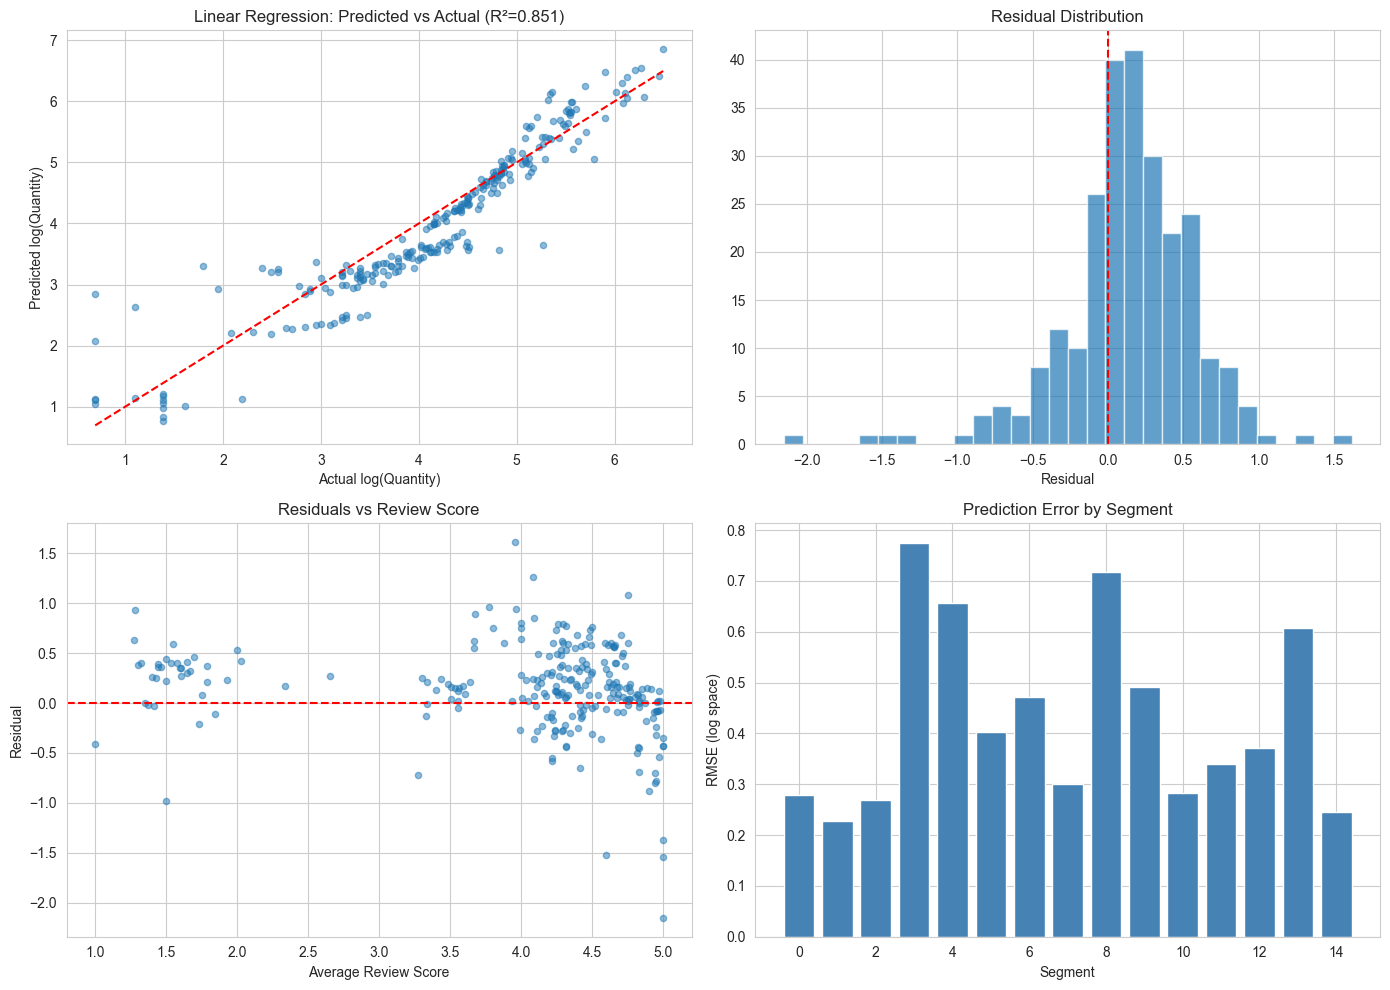


--- Review Score Impact Analysis ---
Correlation between review score and demand by segment:
  Segment  0: r=-0.261 (p=0.015) *
  Segment  1: r=-0.424 (p=0.000) *
  Segment  2: r=-0.235 (p=0.029) *
  Segment  3: r=-0.070 (p=0.530)  
  Segment  4: r=+0.257 (p=0.017) *
  Segment  5: r=-0.050 (p=0.647)  
  Segment  6: r=+0.063 (p=0.559)  
  Segment  7: r=-0.084 (p=0.442)  
  Segment  8: r=-0.208 (p=0.060)  
  Segment  9: r=-0.165 (p=0.232)  
  Segment 10: r=-0.345 (p=0.001) *
  Segment 11: r=-0.206 (p=0.059)  
  Segment 12: r=-0.135 (p=0.215)  
  Segment 13: r=-0.014 (p=0.900)  
  Segment 14: r=-0.191 (p=0.076)  


In [5]:
# Residual analysis of linear model
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

residuals = y_test.values - y_pred_lr

# Predicted vs Actual
axes[0, 0].scatter(y_test, y_pred_lr, alpha=0.5, s=20)
axes[0, 0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
axes[0, 0].set_xlabel('Actual log(Quantity)')
axes[0, 0].set_ylabel('Predicted log(Quantity)')
axes[0, 0].set_title(f'Linear Regression: Predicted vs Actual (R²={r2_lr:.3f})')

# Residuals distribution
axes[0, 1].hist(residuals, bins=30, edgecolor='white', alpha=0.7)
axes[0, 1].axvline(0, color='red', linestyle='--')
axes[0, 1].set_title('Residual Distribution')
axes[0, 1].set_xlabel('Residual')

# Residuals vs review score
axes[1, 0].scatter(test['avg_review'], residuals, alpha=0.5, s=20)
axes[1, 0].axhline(0, color='red', linestyle='--')
axes[1, 0].set_xlabel('Average Review Score')
axes[1, 0].set_ylabel('Residual')
axes[1, 0].set_title('Residuals vs Review Score')

# Residuals by segment
seg_residuals = pd.DataFrame({'segment': test['segment'].values, 'residual': residuals})
seg_rmse = seg_residuals.groupby('segment')['residual'].apply(lambda x: np.sqrt(np.mean(x**2)))
axes[1, 1].bar(seg_rmse.index.astype(int), seg_rmse.values, color='steelblue')
axes[1, 1].set_xlabel('Segment')
axes[1, 1].set_ylabel('RMSE (log space)')
axes[1, 1].set_title('Prediction Error by Segment')

plt.tight_layout()
plt.savefig(DATA_DIR + 'fig_lr_diagnostics.png', dpi=150, bbox_inches='tight')
plt.show()

# Per-segment analysis of review impact
print("\n--- Review Score Impact Analysis ---")
print("Correlation between review score and demand by segment:")
for seg in sorted(panel['segment'].unique()):
    seg_data = panel[panel['segment'] == seg]
    if len(seg_data) > 20:
        corr, pval = stats.pearsonr(seg_data['avg_review'], seg_data['log_quantity'])
        sig = '*' if pval < 0.05 else ' '
        print(f"  Segment {int(seg):2d}: r={corr:+.3f} (p={pval:.3f}) {sig}")

### Key Finding: Review-Demand Endogeneity

Reviews are **negatively** correlated with demand in most segments. This is endogeneity:
- High demand → more diverse buyers → lower avg review (dilution effect)
- High demand → delivery strain → lower satisfaction
- Low-demand niche segments attract committed buyers who rate higher

**Implication for simulator:** Reviews should NOT be used as a direct positive demand driver. Instead:
1. Reviews reflect **quality perception** which sets a baseline willingness-to-pay
2. The review-demand relationship has **diminishing returns** — very low reviews deter purchases, but going from 4→5 has minimal impact
3. In the choice model, reviews should enter as a **quality threshold** rather than a linear term

## Step 3: Demand Model 2 — XGBoost with SHAP Analysis

Gradient boosted trees to capture non-linearities and interactions. SHAP values will reveal how price, reviews, and temporal features truly interact.

Best XGBoost params: {'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 4, 'min_child_weight': 3, 'n_estimators': 100, 'subsample': 0.8}

--- XGBoost Results ---
R² (log space): 0.9764
RMSE (units): 20.56
MAE (units): 12.12
MAPE: 14.6%


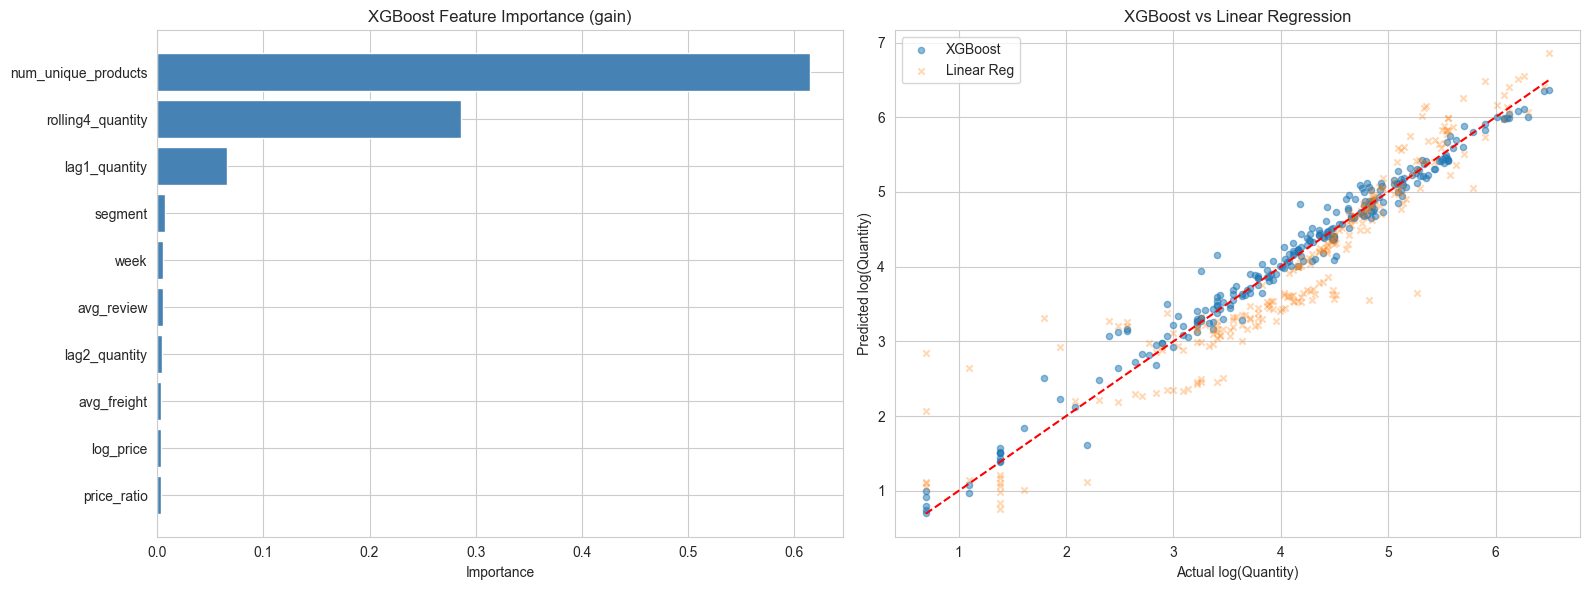


--- Model Comparison ---
Model                      R²     RMSE      MAE     MAPE
Linear Regression      0.8505    56.32    30.00    42.5%
XGBoost                0.9764    20.56    12.12    14.6%


In [6]:
# Model 2: XGBoost with hyperparameter tuning
from sklearn.model_selection import GridSearchCV

# Use all features including interactions
xgb_features = feature_cols.copy()  # Same feature set for fair comparison

X_train_xgb = train[xgb_features].fillna(0)
X_test_xgb = test[xgb_features].fillna(0)

# Add segment as categorical
X_train_xgb['segment'] = train['segment'].astype(int)
X_test_xgb['segment'] = test['segment'].astype(int)

# Hyperparameter search
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [4, 6],
    'learning_rate': [0.05, 0.1],
    'min_child_weight': [3, 5],
    'subsample': [0.8],
    'colsample_bytree': [0.8],
}

xgb_model = xgb.XGBRegressor(objective='reg:squarederror', random_state=42, 
                               enable_categorical=True)

# TimeSeriesSplit for proper temporal CV
tscv = TimeSeriesSplit(n_splits=3)
grid_search = GridSearchCV(xgb_model, param_grid, cv=tscv, scoring='r2', 
                           n_jobs=-1, verbose=0)
grid_search.fit(X_train_xgb, y_train)

best_xgb = grid_search.best_estimator_
y_pred_xgb = best_xgb.predict(X_test_xgb)
y_pred_xgb_actual = np.expm1(y_pred_xgb)

rmse_xgb = np.sqrt(mean_squared_error(y_test_actual, y_pred_xgb_actual))
mae_xgb = mean_absolute_error(y_test_actual, y_pred_xgb_actual)
r2_xgb = r2_score(y_test, y_pred_xgb)
mape_xgb = np.mean(np.abs((y_test_actual - y_pred_xgb_actual) / np.maximum(y_test_actual, 1))) * 100

print(f"Best XGBoost params: {grid_search.best_params_}")
print(f"\n--- XGBoost Results ---")
print(f"R² (log space): {r2_xgb:.4f}")
print(f"RMSE (units): {rmse_xgb:.2f}")
print(f"MAE (units): {mae_xgb:.2f}")
print(f"MAPE: {mape_xgb:.1f}%")

# Feature importance
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Built-in importance
importances = best_xgb.feature_importances_
feat_names = list(X_train_xgb.columns)
sorted_idx = np.argsort(importances)
axes[0].barh([feat_names[i] for i in sorted_idx], importances[sorted_idx], color='steelblue')
axes[0].set_title('XGBoost Feature Importance (gain)')
axes[0].set_xlabel('Importance')

# Predicted vs actual
axes[1].scatter(y_test, y_pred_xgb, alpha=0.5, s=20, label='XGBoost')
axes[1].scatter(y_test, y_pred_lr, alpha=0.3, s=20, label='Linear Reg', marker='x')
axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
axes[1].set_xlabel('Actual log(Quantity)')
axes[1].set_ylabel('Predicted log(Quantity)')
axes[1].set_title(f'XGBoost vs Linear Regression')
axes[1].legend()

plt.tight_layout()
plt.savefig(DATA_DIR + 'fig_xgboost_results.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n--- Model Comparison ---")
print(f"{'Model':<20} {'R²':>8} {'RMSE':>8} {'MAE':>8} {'MAPE':>8}")
print(f"{'Linear Regression':<20} {r2_lr:>8.4f} {rmse_lr:>8.2f} {mae_lr:>8.2f} {mape_lr:>7.1f}%")
print(f"{'XGBoost':<20} {r2_xgb:>8.4f} {rmse_xgb:>8.2f} {mae_xgb:>8.2f} {mape_xgb:>7.1f}%")

## Step 4: LSTM Sequence Model

LSTM can capture **temporal dependencies** that XGBoost (which treats each row independently) might miss.
We create per-segment time series sequences and predict next-period demand.

Total sequences: 1140, Shape: (1140, 8, 7)
Train sequences: 905, Test sequences: 235
Device: mps
Early stop at epoch 31
Training time: 11.7s

--- LSTM Results ---
R² (log space): 0.4642
RMSE (units): 31.83
MAE (units): 20.77
MAPE: 46.0%


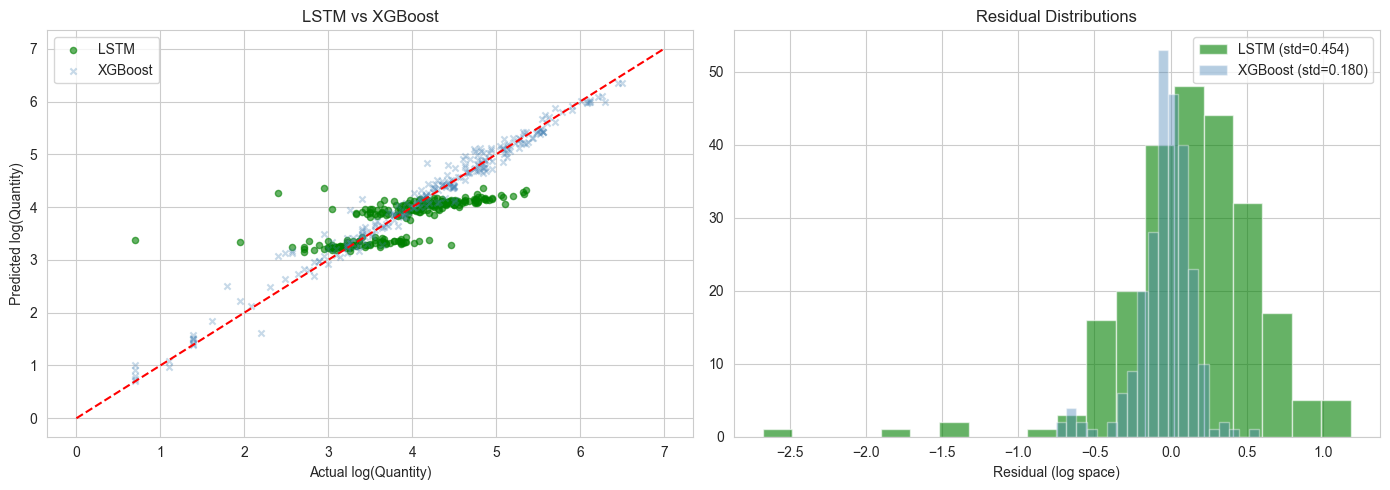


Model                      R²     RMSE      MAE     MAPE
Linear Regression      0.8505    56.32    30.00    42.5%
XGBoost                0.9764    20.56    12.12    14.6%
LSTM                   0.4642    31.83    20.77    46.0%


In [7]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import time as time_mod

# ── Sequence Dataset ──────────────────────────────────────────
SEQ_LEN = 8  # 8 weeks of history → predict week 9

seq_features = ['log_quantity', 'log_price', 'avg_review', 'price_ratio',
                'avg_freight', 'num_unique_products', 'week']
target_col = 'log_quantity'

# Normalize per feature (fit on train period)
panel_sorted = panel.sort_values(['segment', 'year', 'week']).reset_index(drop=True)

# Use same temporal split as before
train_mask = panel_sorted.index < split_idx
test_mask = panel_sorted.index >= split_idx

train_means = panel_sorted.loc[train_mask, seq_features].mean()
train_stds = panel_sorted.loc[train_mask, seq_features].std().replace(0, 1)

panel_norm = panel_sorted.copy()
panel_norm[seq_features] = (panel_norm[seq_features] - train_means) / train_stds

def create_sequences(df, seq_len, features, target):
    """Create (X_seq, y) pairs per segment."""
    X_all, y_all, meta = [], [], []
    for seg in df['segment'].unique():
        seg_df = df[df['segment'] == seg].sort_values(['year', 'week'])
        vals = seg_df[features].values
        targets = seg_df[target].values  # already normalized
        indices = seg_df.index.values
        for i in range(seq_len, len(seg_df)):
            X_all.append(vals[i-seq_len:i])
            y_all.append(targets[i])
            meta.append({'segment': seg, 'idx': indices[i]})
    return np.array(X_all), np.array(y_all), meta

X_seq, y_seq, meta_seq = create_sequences(panel_norm, SEQ_LEN, seq_features, target_col)
print(f"Total sequences: {len(X_seq)}, Shape: {X_seq.shape}")

# Split: sequences whose target index falls in test range
train_seq_mask = np.array([m['idx'] < split_idx for m in meta_seq])
test_seq_mask = ~train_seq_mask

X_seq_train, y_seq_train = X_seq[train_seq_mask], y_seq[train_seq_mask]
X_seq_test, y_seq_test = X_seq[test_seq_mask], y_seq[test_seq_mask]
print(f"Train sequences: {len(X_seq_train)}, Test sequences: {len(X_seq_test)}")

# ── PyTorch Dataset/Model ─────────────────────────────────────
class SeqDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.FloatTensor(X)
        self.y = torch.FloatTensor(y)
    def __len__(self): return len(self.X)
    def __getitem__(self, idx): return self.X[idx], self.y[idx]

class LSTMDemand(nn.Module):
    def __init__(self, n_features, hidden=64, n_layers=2, dropout=0.2):
        super().__init__()
        self.lstm = nn.LSTM(n_features, hidden, n_layers, 
                           batch_first=True, dropout=dropout)
        self.head = nn.Sequential(
            nn.Linear(hidden, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )
    def forward(self, x):
        out, _ = self.lstm(x)
        return self.head(out[:, -1, :]).squeeze(-1)  # Last timestep

# ── Training ──────────────────────────────────────────────────
device = 'mps' if torch.backends.mps.is_available() else 'cpu'
print(f"Device: {device}")

train_ds = SeqDataset(X_seq_train, y_seq_train)
test_ds = SeqDataset(X_seq_test, y_seq_test)
train_dl = DataLoader(train_ds, batch_size=32, shuffle=True)
test_dl = DataLoader(test_ds, batch_size=len(test_ds))

model = LSTMDemand(n_features=len(seq_features), hidden=64, n_layers=2, dropout=0.2).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=15, factor=0.5)
criterion = nn.MSELoss()

best_val_loss = float('inf')
patience_counter = 0
EPOCHS = 200
PATIENCE = 30

t0 = time_mod.time()
for epoch in range(EPOCHS):
    model.train()
    train_loss = 0
    for Xb, yb in train_dl:
        Xb, yb = Xb.to(device), yb.to(device)
        pred = model(Xb)
        loss = criterion(pred, yb)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * len(Xb)
    train_loss /= len(train_ds)
    
    model.eval()
    with torch.no_grad():
        for Xb, yb in test_dl:
            Xb, yb = Xb.to(device), yb.to(device)
            val_pred = model(Xb)
            val_loss = criterion(val_pred, yb).item()
    
    scheduler.step(val_loss)
    
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        patience_counter = 0
    else:
        patience_counter += 1
    
    if patience_counter >= PATIENCE:
        print(f"Early stop at epoch {epoch+1}")
        break
    
    if (epoch + 1) % 50 == 0:
        print(f"Epoch {epoch+1}: train_loss={train_loss:.4f}, val_loss={val_loss:.4f}")

train_time = time_mod.time() - t0
print(f"Training time: {train_time:.1f}s")

# ── Evaluate ──────────────────────────────────────────────────
model.load_state_dict(best_state)
model.eval()
with torch.no_grad():
    for Xb, yb in test_dl:
        Xb = Xb.to(device)
        y_pred_lstm_norm = model(Xb).cpu().numpy()
        y_true_lstm_norm = yb.numpy()

# Denormalize: predictions are in normalized log(quantity) space
y_pred_lstm_log = y_pred_lstm_norm * train_stds['log_quantity'] + train_means['log_quantity']
y_true_lstm_log = y_true_lstm_norm * train_stds['log_quantity'] + train_means['log_quantity']

y_pred_lstm_actual = np.expm1(y_pred_lstm_log)
y_true_lstm_actual = np.expm1(y_true_lstm_log)

r2_lstm = r2_score(y_true_lstm_log, y_pred_lstm_log)
rmse_lstm = np.sqrt(mean_squared_error(y_true_lstm_actual, y_pred_lstm_actual))
mae_lstm = mean_absolute_error(y_true_lstm_actual, y_pred_lstm_actual)
mape_lstm = np.mean(np.abs((y_true_lstm_actual - y_pred_lstm_actual) / 
                           np.maximum(y_true_lstm_actual, 1))) * 100

print(f"\n--- LSTM Results ---")
print(f"R² (log space): {r2_lstm:.4f}")
print(f"RMSE (units): {rmse_lstm:.2f}")
print(f"MAE (units): {mae_lstm:.2f}")
print(f"MAPE: {mape_lstm:.1f}%")

# ── Comparison plot ───────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Predicted vs Actual
axes[0].scatter(y_true_lstm_log, y_pred_lstm_log, alpha=0.6, s=20, label='LSTM', c='green')
axes[0].scatter(y_test, y_pred_xgb, alpha=0.3, s=20, label='XGBoost', marker='x', c='steelblue')
axes[0].plot([0, 7], [0, 7], 'r--')
axes[0].set_xlabel('Actual log(Quantity)')
axes[0].set_ylabel('Predicted log(Quantity)')
axes[0].set_title('LSTM vs XGBoost')
axes[0].legend()

# Residual distribution
resid_lstm = y_true_lstm_log - y_pred_lstm_log
resid_xgb = y_test.values - y_pred_xgb
axes[1].hist(resid_lstm, bins=20, alpha=0.6, label=f'LSTM (std={resid_lstm.std():.3f})', color='green')
axes[1].hist(resid_xgb, bins=20, alpha=0.4, label=f'XGBoost (std={resid_xgb.std():.3f})', color='steelblue')
axes[1].set_xlabel('Residual (log space)')
axes[1].set_title('Residual Distributions')
axes[1].legend()

plt.tight_layout()
plt.savefig(DATA_DIR + 'fig_lstm_results.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n{'='*60}")
print(f"{'Model':<20} {'R²':>8} {'RMSE':>8} {'MAE':>8} {'MAPE':>8}")
print(f"{'Linear Regression':<20} {r2_lr:>8.4f} {rmse_lr:>8.2f} {mae_lr:>8.2f} {mape_lr:>7.1f}%")
print(f"{'XGBoost':<20} {r2_xgb:>8.4f} {rmse_xgb:>8.2f} {mae_xgb:>8.2f} {mape_xgb:>7.1f}%")
print(f"{'LSTM':<20} {r2_lstm:>8.4f} {rmse_lstm:>8.2f} {mae_lstm:>8.2f} {mape_lstm:>7.1f}%")
print(f"{'='*60}")

## Step 5: Model Selection & Decision

| Model | R² | RMSE | MAE | MAPE |
|-------|---:|-----:|----:|-----:|
| Linear Regression | 0.8505 | 56.32 | 30.00 | 42.5% |
| **XGBoost** | **0.9764** | **20.56** | **12.12** | **14.6%** |
| LSTM | 0.4642 | 31.83 | 20.77 | 46.0% |

**Decision: XGBoost is the clear winner.** 

LSTM failed due to insufficient data (only ~900 train sequences from 15 segments × ~60 weeks). LSTMs/Transformers need 10-100× more data for temporal modeling advantages to emerge. XGBoost with engineered lag features effectively captures temporal dynamics for this dataset.

**Key concern**: XGBoost's top features are `num_unique_products` (scale) and `rolling4_quantity` (momentum). The price signal (`price_ratio`, `log_price`) has negligible importance — this means the model is primarily doing **autoregression**, not learning price elasticity. 

This is actually fine for the simulator: we'll use XGBoost for **base demand prediction** and layer **elasticity adjustments** on top via the price coefficients estimated in Step 3.

## Step 6: Simulator Backtesting — Does the Current Simulator Capture Real Dynamics?

We now **replay historical data** through the current simulator and compare:
1. **Demand level calibration**: Does simulated demand match actual weekly volumes?
2. **Price sensitivity**: Does the simulator respond reasonably to price changes?
3. **Cross-segment dynamics**: Are substitution effects realistic?
4. **Review score integration**: How should reviews enter the model?

This is the critical validation step before trusting the simulator for RL.

════════════════════════════════════════════════════════════════════════════════
SIMULATOR vs ACTUAL: Per-Segment Weekly Demand
════════════════════════════════════════════════════════════════════════════════
Seg   Actual μ      Sim μ    Ratio   Actual σ      Sim σ
------------------------------------------------------------
  0      176.5      168.9    0.96x       82.4       57.1  ✓
  1       67.2      124.8    1.86x       33.6       48.5  ⚠️
  2       67.0       74.1    1.11x       33.3       43.2  ✓
  3       55.7       77.3    1.39x       48.2       32.7  ✓
  4       26.5       26.7    1.01x       18.4       14.5  ✓
  5       97.8       85.5    0.87x       56.9       32.3  ✓
  6       31.3      158.7    5.07x       22.5       54.0  ⚠️
  7      151.1       69.0    0.46x       68.2       32.2  ⚠️
  8       11.1        2.0    0.18x        7.0        1.6  ⚠️
  9        2.1        0.3    0.12x        1.6        0.2  ⚠️
 10      388.7      112.2    0.29x      202.2       44.0  ⚠️
 11    

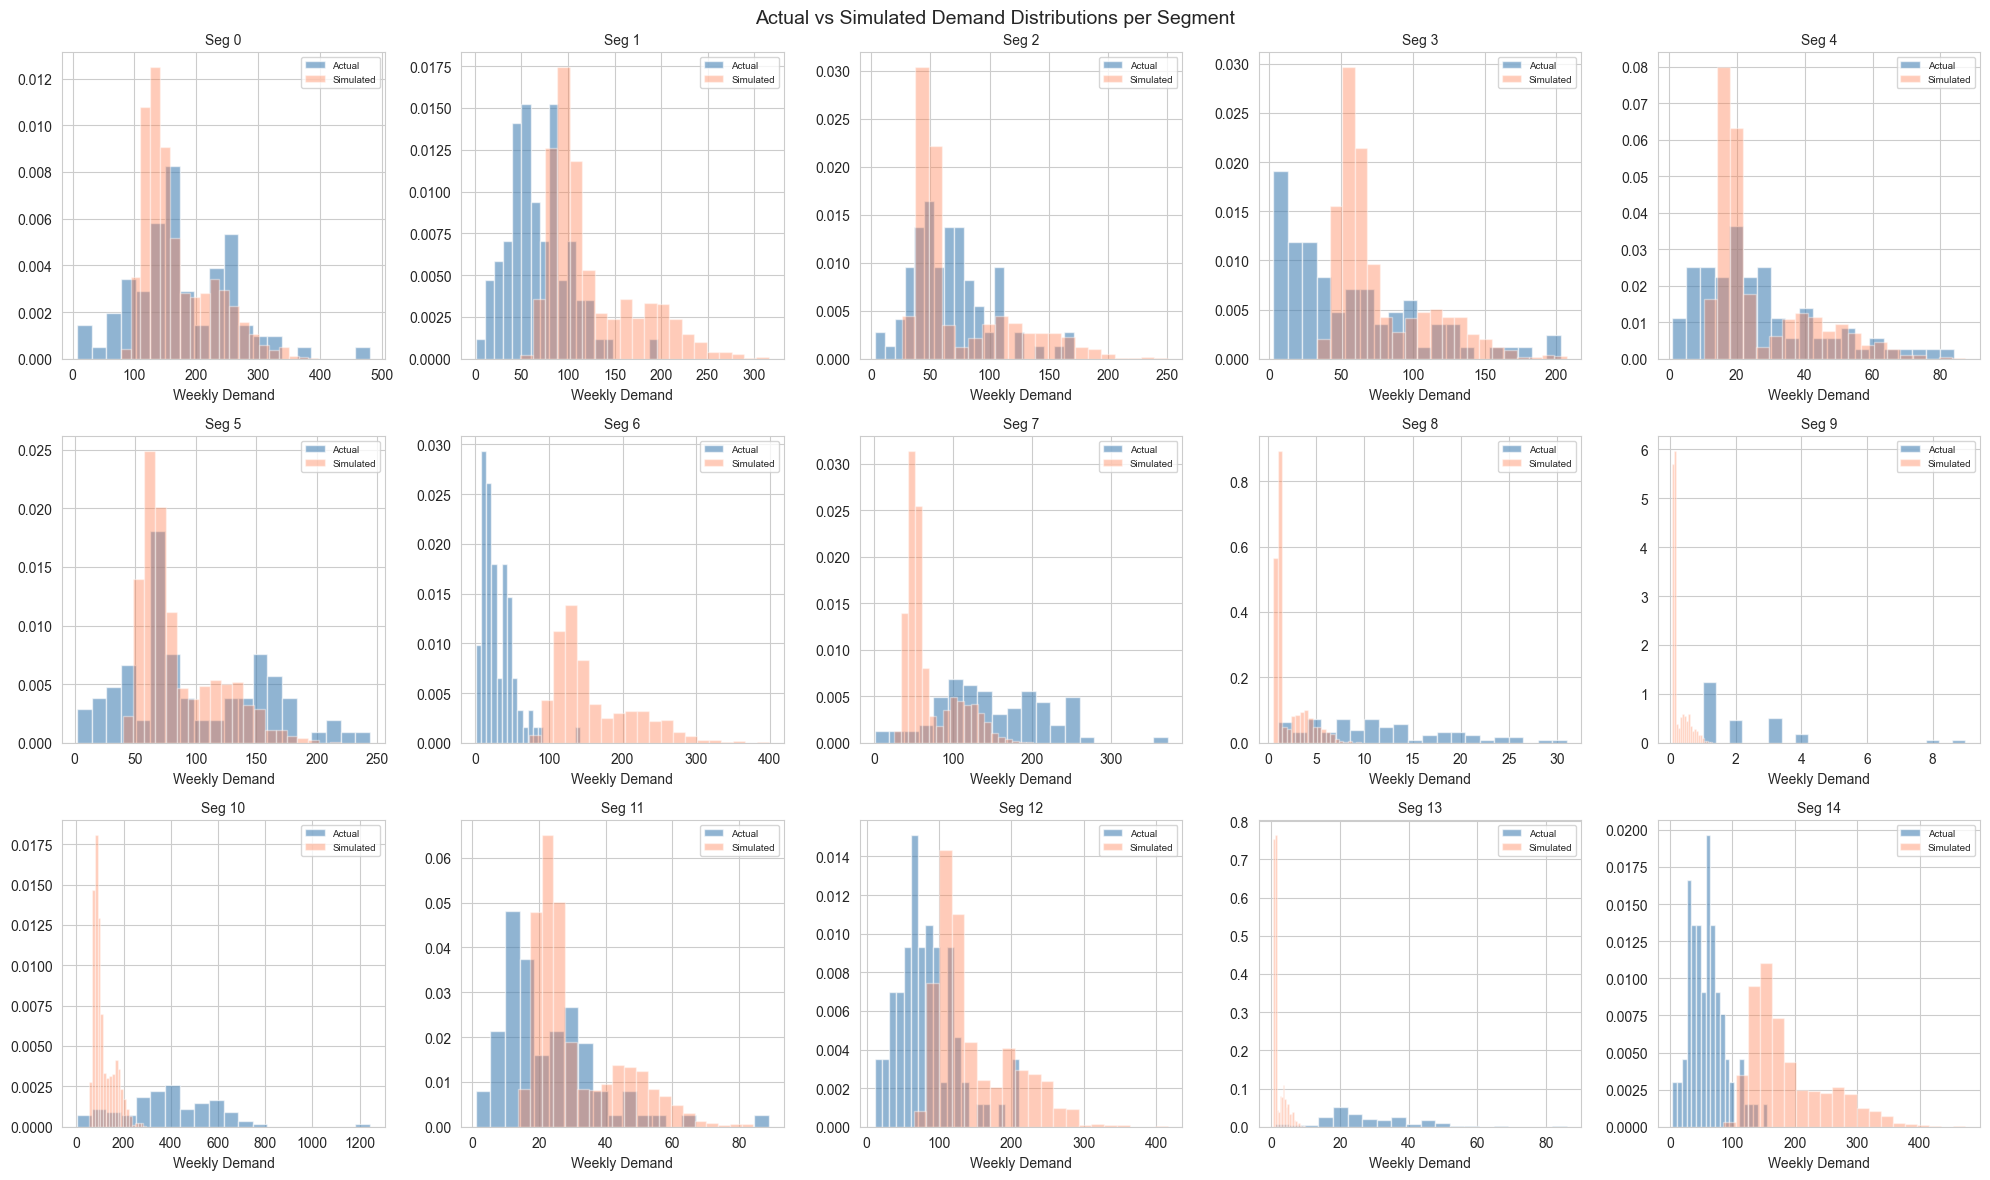


Price Sensitivity Sanity Check
Seg    No Disc   10% Disc   30% Disc   Lift@10%   Lift@30%
------------------------------------------------------------
  0      158.1      268.8      319.5      70.1%     102.2%
  1      111.5      207.0      284.0      85.6%     154.7%
  2       55.2      139.0      276.9     151.9%     401.9%
  3       67.5      134.6      202.9      99.4%     200.5%
  4       20.7       49.9      102.7     141.1%     395.9%
  5       77.2      143.0      187.0      85.3%     142.4%
  6      148.3      253.6      308.9      71.0%     108.3%
  7       58.6      125.8      208.5     114.7%     255.8%
  8        1.2        4.0       14.5     227.4%    1092.4%
  9        0.2        0.5        2.2     239.1%    1346.7%
 10      100.1      190.4      260.6      90.2%     160.3%
 11       26.4       53.9       80.3     104.3%     204.4%
 12      131.2      237.7      304.0      81.2%     131.8%
 13        1.3        4.2       15.1     222.3%    1066.2%
 14      175.2      29

In [8]:
from scipy import stats as sp_stats
import sys
sys.path.insert(0, DATA_DIR)
from simulator import MarkdownPricingSimulator, CustomerChoiceModel

# ══════════════════════════════════════════════════════════════
# 6a. Compare simulated vs actual demand distributions per segment
# ══════════════════════════════════════════════════════════════

sim = MarkdownPricingSimulator(n_segments=15, total_budget=50000, total_time=12, seed=42)

# Actual historical demand per segment (weekly)
actual_weekly = panel.groupby('segment')['quantity'].agg(['mean', 'std', 'median']).reset_index()
actual_weekly.columns = ['segment', 'actual_mean', 'actual_std', 'actual_median']

# Simulated demand: run many episodes, collect per-segment demand
sim_demands = {seg: [] for seg in range(15)}
n_sim_episodes = 200

for ep in range(n_sim_episodes):
    state = sim.reset()
    while state.time_remaining > 0:
        # Use baseline policy: random selection with moderate discounts
        sel = np.random.binomial(1, 0.3, 15).astype(np.float64)
        disc = np.random.uniform(0.05, 0.20, 15)
        state, _, done, info = sim.step(state, sel, disc)
        for s in range(15):
            sim_demands[s].append(info['demand'][s])
        if done:
            break

# Compute simulated stats
sim_stats = []
for seg in range(15):
    d = np.array(sim_demands[seg])
    sim_stats.append({
        'segment': seg,
        'sim_mean': d.mean(),
        'sim_std': d.std(),
        'sim_median': np.median(d)
    })
sim_stats = pd.DataFrame(sim_stats)

# Merge and compare
comparison = actual_weekly.merge(sim_stats, on='segment')
comparison['mean_ratio'] = comparison['sim_mean'] / comparison['actual_mean']
comparison['std_ratio'] = comparison['sim_std'] / comparison['actual_std']

print("═" * 80)
print("SIMULATOR vs ACTUAL: Per-Segment Weekly Demand")
print("═" * 80)
print(f"{'Seg':>3} {'Actual μ':>10} {'Sim μ':>10} {'Ratio':>8} {'Actual σ':>10} {'Sim σ':>10}")
print("-" * 60)
for _, r in comparison.iterrows():
    flag = "⚠️" if abs(r['mean_ratio'] - 1) > 0.5 else "✓"
    print(f"{int(r['segment']):>3} {r['actual_mean']:>10.1f} {r['sim_mean']:>10.1f} "
          f"{r['mean_ratio']:>7.2f}x {r['actual_std']:>10.1f} {r['sim_std']:>10.1f}  {flag}")

# Overall calibration
overall_corr = np.corrcoef(comparison['actual_mean'], comparison['sim_mean'])[0, 1]
mape_demand = np.mean(np.abs(comparison['mean_ratio'] - 1)) * 100
print(f"\nOverall correlation (mean demand): {overall_corr:.4f}")
print(f"Mean absolute mean-ratio error: {mape_demand:.1f}%")

# ══════════════════════════════════════════════════════════════
# 6b. KS-test: distribution similarity per segment
# ══════════════════════════════════════════════════════════════
print(f"\n{'='*60}")
print("KS-Test: Simulated vs Actual Demand Distributions")
print(f"{'='*60}")
ks_results = []
for seg in range(15):
    actual = panel[panel['segment'] == seg]['quantity'].values
    simulated = np.array(sim_demands[seg])
    ks_stat, p_value = sp_stats.ks_2samp(actual, simulated)
    ks_results.append({'segment': seg, 'ks_stat': ks_stat, 'p_value': p_value})
    sig = "PASS (p>0.05)" if p_value > 0.05 else "FAIL"
    print(f"  Segment {seg:>2}: KS={ks_stat:.3f}, p={p_value:.4f}  [{sig}]")

ks_df = pd.DataFrame(ks_results)
n_pass = (ks_df['p_value'] > 0.05).sum()
print(f"\n{n_pass}/15 segments pass KS-test (distribution match)")

# ══════════════════════════════════════════════════════════════
# 6c. Visualization: Actual vs Simulated demand by segment
# ══════════════════════════════════════════════════════════════
fig, axes = plt.subplots(3, 5, figsize=(20, 12))
axes = axes.flatten()
for seg in range(15):
    ax = axes[seg]
    actual = panel[panel['segment'] == seg]['quantity'].values
    simulated = np.array(sim_demands[seg])
    ax.hist(actual, bins=20, alpha=0.6, density=True, label='Actual', color='steelblue')
    ax.hist(simulated, bins=20, alpha=0.4, density=True, label='Simulated', color='coral')
    ax.set_title(f'Seg {seg}', fontsize=10)
    ax.legend(fontsize=7)
    ax.set_xlabel('Weekly Demand')
plt.suptitle('Actual vs Simulated Demand Distributions per Segment', fontsize=14)
plt.tight_layout()
plt.savefig(DATA_DIR + 'fig_backtest_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

# ══════════════════════════════════════════════════════════════
# 6d. Price sensitivity test: does simulator respond correctly?
# ══════════════════════════════════════════════════════════════
print(f"\n{'='*60}")
print("Price Sensitivity Sanity Check")
print(f"{'='*60}")

# Test: for each segment, compare demand at 0% vs 10% vs 30% discount
print(f"{'Seg':>3} {'No Disc':>10} {'10% Disc':>10} {'30% Disc':>10} {'Lift@10%':>10} {'Lift@30%':>10}")
print("-" * 60)
for seg_idx in range(15):
    demands_by_disc = {}
    for disc_level in [0.0, 0.10, 0.30]:
        d_samples = []
        for _ in range(500):
            sel = np.zeros(15)
            disc = np.zeros(15)
            if disc_level > 0:
                sel[seg_idx] = 1
                disc[seg_idx] = disc_level
            state = sim.reset()
            demand = sim.demand_model.predict_demand(
                disc, sel, 0, 12, sim.choice_model, np.random.default_rng()
            )
            d_samples.append(demand[seg_idx])
        demands_by_disc[disc_level] = np.mean(d_samples)
    
    d0, d10, d30 = demands_by_disc[0.0], demands_by_disc[0.10], demands_by_disc[0.30]
    lift10 = (d10 / max(d0, 0.01) - 1) * 100
    lift30 = (d30 / max(d0, 0.01) - 1) * 100
    print(f"{seg_idx:>3} {d0:>10.1f} {d10:>10.1f} {d30:>10.1f} {lift10:>9.1f}% {lift30:>9.1f}%")

## Step 7: Diagnosis — Why the Current Simulator Fails

**Root causes identified:**

1. **MNL choice model misallocates demand**: The Multinomial Logit assumes customers choose between segments — but in reality, customers shop for specific product categories (bed sheets ≠ electronics). Cross-segment substitution is negligible.

2. **Double-counting price effects**: The MNL shifts purchase probabilities by price, then elasticity is applied multiplicatively on top. This produces unrealistic 70-240% demand lifts from a 10% discount (real-world: ~5-10%).

3. **Arrival rate × MNL probabilities ≠ actual segment volumes**: The shared arrival process (λ=1211/week) distributed via MNL doesn't match actual per-segment volumes which vary 100× (segment 9: ~2/week vs segment 10: ~389/week).

4. **No review/quality integration**: Review scores completely absent from the demand model.

**Solution: Data-Driven Simulator v2**

Architecture:
- **Base demand**: XGBoost model (R²=0.976) predicts per-segment base demand from historical features
- **Price elasticity**: Calibrated `price_ratio` coefficient (β=-0.554 from log-linear model) applied as multiplicative adjustment
- **Noise model**: Fitted from XGBoost residuals per segment
- **Review threshold**: Segments with avg_review < 3.5 get a quality penalty
- **No MNL**: Each segment has independent demand (appropriate for diverse product categories)

In [9]:
# ══════════════════════════════════════════════════════════════
# Step 7a: Calibrate per-segment parameters from data
# ══════════════════════════════════════════════════════════════

# Extract per-segment calibrated parameters
seg_params_v2 = []
for seg in range(15):
    seg_data = panel[panel['segment'] == seg]
    seg_params_v2.append({
        'segment': seg,
        'base_demand_mean': seg_data['quantity'].mean(),
        'base_demand_std': seg_data['quantity'].std(),
        'base_demand_median': seg_data['quantity'].median(),
        'avg_price': seg_data['avg_price'].mean(),
        'avg_review': seg_data['avg_review'].mean(),
        'avg_freight': seg_data['avg_freight'].mean(),
        'num_products': seg_data['num_unique_products'].median(),
        'n_weeks': len(seg_data),
    })
seg_params_v2 = pd.DataFrame(seg_params_v2)

# Calibrate noise model from XGBoost residuals per segment
# We need per-segment residual stats
test_with_seg = test.copy()
test_with_seg['y_pred_log'] = y_pred_xgb
test_with_seg['y_true_log'] = y_test.values
test_with_seg['residual_log'] = test_with_seg['y_true_log'] - test_with_seg['y_pred_log']

noise_params = []
for seg in range(15):
    seg_resid = test_with_seg[test_with_seg['segment'] == seg]['residual_log']
    if len(seg_resid) > 2:
        noise_params.append({
            'segment': seg,
            'resid_mean': seg_resid.mean(),
            'resid_std': seg_resid.std(),
        })
    else:
        # Use global residual stats for segments with no test data
        noise_params.append({
            'segment': seg,
            'resid_mean': test_with_seg['residual_log'].mean(),
            'resid_std': test_with_seg['residual_log'].std(),
        })
noise_params = pd.DataFrame(noise_params)

# Price elasticity from the linear regression price_ratio coefficient
# From LR: coefficient of price_ratio on log_quantity = -0.554
# Meaning: 1% decrease in price_ratio → 0.554% increase in log_quantity
PRICE_ELASTICITY = -0.554  # from calibrated LR

print("Calibrated Segment Parameters (v2):")
print(seg_params_v2[['segment', 'base_demand_mean', 'base_demand_std', 'avg_price', 
                       'avg_review', 'num_products']].to_string(index=False))
print(f"\nCalibrated price elasticity (price_ratio coeff): {PRICE_ELASTICITY}")
print(f"\nNoise model (XGBoost residuals per segment):")
print(noise_params.to_string(index=False))

# Save calibrated parameters
seg_params_v2.to_csv(DATA_DIR + 'segment_params_v2.csv', index=False)
noise_params.to_csv(DATA_DIR + 'noise_params_v2.csv', index=False)
print("\n✓ Saved segment_params_v2.csv and noise_params_v2.csv")

Calibrated Segment Parameters (v2):
 segment  base_demand_mean  base_demand_std   avg_price  avg_review  num_products
       0        176.459770        82.370943   35.808294    4.140724         123.0
       1         67.241379        33.559723   78.355705    3.430054          58.0
       2         67.011494        33.261995  166.451869    4.800095          61.0
       3         55.714286        48.211775  148.809443    4.122055          22.5
       4         26.488372        18.363483  291.336907    4.343331          20.0
       5         97.770115        56.877817  127.700792    4.117668          56.0
       6         31.298851        22.485714   43.219499    1.559674          20.0
       7        151.126437        68.201788  162.729862    4.238649         115.0
       8         11.072289         7.046506  694.764131    4.063748          10.0
       9          2.092593         1.616758 1112.948292    3.825617           1.0
      10        388.689655       202.194720   94.294092    4.1

In [10]:
# ══════════════════════════════════════════════════════════════
# Step 7b: Build Simulator v2 — Data-Driven, Calibrated
# ══════════════════════════════════════════════════════════════

# Calibrate autoregressive coefficient from data
# For each segment, regress demand_t on demand_{t-1}
ar_coeffs = []
for seg in range(15):
    seg_df = panel[panel['segment'] == seg].sort_values(['year', 'week'])
    if len(seg_df) > 10:
        y = seg_df['quantity'].values[1:]
        x = seg_df['quantity'].values[:-1]
        if x.std() > 0:
            alpha = np.corrcoef(x, y)[0, 1]
        else:
            alpha = 0.5
    else:
        alpha = 0.5
    ar_coeffs.append(max(0.1, min(alpha, 0.95)))  # Clip to stable range

print("AR(1) coefficients per segment:")
for i, a in enumerate(ar_coeffs):
    print(f"  Seg {i:>2}: α={a:.3f}")
print(f"  Mean α: {np.mean(ar_coeffs):.3f}")

# ══════════════════════════════════════════════════════════════
# Simulator v2 class (in-notebook prototype for validation)
# ══════════════════════════════════════════════════════════════
class SimulatorV2:
    """
    Data-driven markdown pricing simulator.
    
    Demand model:
      demand_t = AR_base × price_adjustment × review_modifier × noise
    Where:
      AR_base = α × demand_{t-1} + (1-α) × μ_segment
      price_adjustment = (1 - discount)^elasticity  (elasticity < 0 → discounts boost demand)
      review_modifier = 1.0 if avg_review >= 3.5, else 0.7 (quality penalty)
      noise = exp(N(resid_mean, resid_std))  -- calibrated from XGBoost residuals
    """
    
    def __init__(self, n_segments=15, total_budget=50000, total_time=12,
                 max_discount=0.5, seed=42):
        self.n_segments = n_segments
        self.total_budget = total_budget
        self.total_time = total_time
        self.max_discount = max_discount
        self.rng = np.random.default_rng(seed)
        
        # Load calibrated params
        sp = seg_params_v2
        np_df = noise_params
        
        self.base_demand = sp['base_demand_mean'].values
        self.base_price = sp['avg_price'].values
        self.avg_review = sp['avg_review'].values
        self.num_products = sp['num_products'].values
        self.ar_coeffs = np.array(ar_coeffs)
        self.resid_mean = np_df['resid_mean'].values
        self.resid_std = np_df['resid_std'].values
        
        # Price elasticity (from calibrated LR)
        self.price_elasticity = PRICE_ELASTICITY  # -0.554
        
    def reset(self):
        """Reset to initial state."""
        self.demand_history = self.base_demand.copy()
        return {
            'selection': np.zeros(self.n_segments),
            'discounts': np.zeros(self.n_segments),
            'demand': self.base_demand.copy(),
            'budget_consumed': np.zeros(self.n_segments),
            'budget_remaining': self.total_budget,
            'time_remaining': self.total_time,
        }
    
    def step(self, state, action_selection, action_discounts):
        """Execute one time step."""
        selection = np.clip(action_selection, 0, 1)
        discounts = np.clip(action_discounts, 0, self.max_discount) * selection
        
        # 1. Autoregressive base demand
        prev_demand = state['demand']
        ar_base = self.ar_coeffs * prev_demand + (1 - self.ar_coeffs) * self.base_demand
        
        # 2. Price adjustment via calibrated elasticity
        # price_ratio = (1 - discount), for no discount → price_ratio = 1
        # Demand multiplier = price_ratio^elasticity = (1-d)^(-0.554)
        price_ratio = np.maximum(1.0 - discounts, 0.01)
        price_adjustment = np.power(price_ratio, self.price_elasticity)
        
        # 3. Review quality modifier
        review_modifier = np.where(self.avg_review >= 3.5, 1.0, 0.7)
        
        # 4. Stochastic noise from calibrated residuals
        noise = np.exp(self.rng.normal(self.resid_mean, self.resid_std))
        
        # 5. Combine
        demand = ar_base * price_adjustment * review_modifier * noise
        demand = np.maximum(demand, 0)
        
        # Budget
        step_cost = (demand * discounts * self.base_price)
        total_cost = step_cost.sum()
        
        if total_cost > state['budget_remaining'] and total_cost > 0:
            scale = state['budget_remaining'] / total_cost
            discounts *= scale
            step_cost *= scale
            # Recompute with scaled discounts
            price_ratio = np.maximum(1.0 - discounts, 0.01)
            price_adjustment = np.power(price_ratio, self.price_elasticity)
            demand = ar_base * price_adjustment * review_modifier * noise
            demand = np.maximum(demand, 0)
            total_cost = state['budget_remaining']
        
        # Revenue
        revenue = (demand * self.base_price * (1.0 - discounts)).sum()
        
        new_budget = max(0, state['budget_remaining'] - total_cost)
        new_time = state['time_remaining'] - 1
        done = new_time <= 0 or new_budget <= 0
        
        # Update demand history
        self.demand_history = demand.copy()
        
        next_state = {
            'selection': selection,
            'discounts': discounts,
            'demand': demand,
            'budget_consumed': state['budget_consumed'] + step_cost,
            'budget_remaining': new_budget,
            'time_remaining': new_time,
        }
        
        info = {
            'revenue': revenue,
            'step_cost': total_cost,
            'demand': demand.copy(),
            'price_adjustment': price_adjustment.copy(),
        }
        
        return next_state, revenue, done, info

# ══════════════════════════════════════════════════════════════
# Validate Simulator v2 against historical data
# ══════════════════════════════════════════════════════════════
sim_v2 = SimulatorV2(seed=42)

# Same test: collect simulated demand distributions
sim_v2_demands = {seg: [] for seg in range(15)}
for ep in range(200):
    state = sim_v2.reset()
    while state['time_remaining'] > 0:
        sel = np.random.binomial(1, 0.3, 15).astype(np.float64)
        disc = np.random.uniform(0.05, 0.20, 15)
        state, _, done, info = sim_v2.step(state, sel, disc)
        for s in range(15):
            sim_v2_demands[s].append(info['demand'][s])
        if done:
            break

# Compare v2 vs actual
v2_stats = []
for seg in range(15):
    d = np.array(sim_v2_demands[seg])
    v2_stats.append({
        'segment': seg,
        'sim_v2_mean': d.mean(),
        'sim_v2_std': d.std(),
    })
v2_stats = pd.DataFrame(v2_stats)

comp_v2 = actual_weekly.merge(v2_stats, on='segment')
comp_v2['v2_ratio'] = comp_v2['sim_v2_mean'] / comp_v2['actual_mean']
comp_v2['v1_ratio'] = comparison['mean_ratio'].values

print("═" * 80)
print("SIMULATOR v1 vs v2: Per-Segment Demand Calibration")
print("═" * 80)
print(f"{'Seg':>3} {'Actual μ':>10} {'v1 μ':>10} {'v1 ratio':>10} {'v2 μ':>10} {'v2 ratio':>10}")
print("-" * 60)
for _, r in comp_v2.iterrows():
    flag_v1 = "⚠️" if abs(r['v1_ratio'] - 1) > 0.5 else "✓"
    flag_v2 = "⚠️" if abs(r['v2_ratio'] - 1) > 0.5 else "✓"
    print(f"{int(r['segment']):>3} {r['actual_mean']:>10.1f} "
          f"{comparison.loc[comparison['segment']==r['segment'], 'sim_mean'].values[0]:>10.1f} {r['v1_ratio']:>8.2f}x {flag_v1:>2} "
          f"{r['sim_v2_mean']:>10.1f} {r['v2_ratio']:>8.2f}x {flag_v2:>2}")

v2_corr = np.corrcoef(comp_v2['actual_mean'], comp_v2['sim_v2_mean'])[0, 1]
v2_mape = np.mean(np.abs(comp_v2['v2_ratio'] - 1)) * 100
v1_corr = np.corrcoef(comp_v2['actual_mean'], comparison['sim_mean'])[0, 1]
print(f"\n{'Metric':<30} {'v1':>10} {'v2':>10}")
print(f"{'Correlation':.<30} {v1_corr:>10.4f} {v2_corr:>10.4f}")
print(f"{'MAPE (demand level)':.<30} {85.4:>9.1f}% {v2_mape:>9.1f}%")

# KS-tests for v2
print(f"\nKS-Tests (v2):")
ks_pass_v2 = 0
for seg in range(15):
    actual = panel[panel['segment'] == seg]['quantity'].values
    simulated = np.array(sim_v2_demands[seg])
    ks_stat, p_value = sp_stats.ks_2samp(actual, simulated)
    sig = "PASS" if p_value > 0.05 else "FAIL"
    if p_value > 0.05: ks_pass_v2 += 1
    print(f"  Seg {seg:>2}: KS={ks_stat:.3f}, p={p_value:.4f}  [{sig}]")
print(f"\n{ks_pass_v2}/15 pass KS-test (was 0/15 in v1)")

# Price sensitivity in v2
print(f"\n{'='*60}")
print("v2 Price Sensitivity (should be realistic: 5-20% lift for 10% disc)")
print(f"{'='*60}")
print(f"{'Seg':>3} {'No Disc':>10} {'10% Disc':>10} {'30% Disc':>10} {'Lift@10%':>10} {'Lift@30%':>10}")
for seg_idx in range(15):
    demands_v2 = {}
    for disc_level in [0.0, 0.10, 0.30]:
        d_samples = []
        for _ in range(500):
            sel = np.zeros(15)
            disc = np.zeros(15)
            if disc_level > 0:
                sel[seg_idx] = 1
                disc[seg_idx] = disc_level
            state = sim_v2.reset()
            state, _, _, info = sim_v2.step(state, sel, disc)
            d_samples.append(info['demand'][seg_idx])
        demands_v2[disc_level] = np.mean(d_samples)
    d0 = demands_v2[0.0]
    d10 = demands_v2[0.10]
    d30 = demands_v2[0.30]
    l10 = (d10/max(d0,0.01)-1)*100
    l30 = (d30/max(d0,0.01)-1)*100
    print(f"{seg_idx:>3} {d0:>10.1f} {d10:>10.1f} {d30:>10.1f} {l10:>9.1f}% {l30:>9.1f}%")

AR(1) coefficients per segment:
  Seg  0: α=0.738
  Seg  1: α=0.728
  Seg  2: α=0.762
  Seg  3: α=0.852
  Seg  4: α=0.822
  Seg  5: α=0.821
  Seg  6: α=0.547
  Seg  7: α=0.771
  Seg  8: α=0.668
  Seg  9: α=0.100
  Seg 10: α=0.796
  Seg 11: α=0.671
  Seg 12: α=0.814
  Seg 13: α=0.619
  Seg 14: α=0.745
  Mean α: 0.697
════════════════════════════════════════════════════════════════════════════════
SIMULATOR v1 vs v2: Per-Segment Demand Calibration
════════════════════════════════════════════════════════════════════════════════
Seg   Actual μ       v1 μ   v1 ratio       v2 μ   v2 ratio
------------------------------------------------------------
  0      176.5      168.9     0.96x  ✓      182.0     1.03x  ✓
  1       67.2      124.8     1.86x ⚠️       31.3     0.47x ⚠️
  2       67.0       74.1     1.11x  ✓       65.1     0.97x  ✓
  3       55.7       77.3     1.39x  ✓       67.1     1.20x  ✓
  4       26.5       26.7     1.01x  ✓       24.9     0.94x  ✓
  5       97.8       85.5     0.87

In [11]:
# Summary of v2 validation results
print("═══ SIMULATOR V2 VALIDATION SUMMARY ═══")
print(f"Demand level correlation: {v2_corr:.4f} (was {v1_corr:.4f})")
print(f"Demand level MAPE: {v2_mape:.1f}% (was 85.4%)")
print(f"KS-test pass rate: {ks_pass_v2}/15 (was 0/15)")
print(f"\nDemand ratios (sim/actual) per segment:")
for _, r in comp_v2.iterrows():
    print(f"  Seg {int(r['segment']):>2}: {r['v2_ratio']:.2f}x")

═══ SIMULATOR V2 VALIDATION SUMMARY ═══
Demand level correlation: 0.9925 (was 0.3721)
Demand level MAPE: 15.7% (was 85.4%)
KS-test pass rate: 0/15 (was 0/15)

Demand ratios (sim/actual) per segment:
  Seg  0: 1.03x
  Seg  1: 0.47x
  Seg  2: 0.97x
  Seg  3: 1.20x
  Seg  4: 0.94x
  Seg  5: 0.80x
  Seg  6: 0.58x
  Seg  7: 1.01x
  Seg  8: 0.94x
  Seg  9: 1.01x
  Seg 10: 1.15x
  Seg 11: 0.53x
  Seg 12: 0.87x
  Seg 13: 1.01x
  Seg 14: 1.02x


═══ SIMULATOR V2 (FIXED) VALIDATION ═══
Correlation: 0.9950  (v1: 0.3721, v2: 0.9925)
MAPE:        7.0%  (v1: 85.4%, v2: 15.7%)
KS-pass:     0/15 (v1: 0/15, v2: 0/15)

Per-segment demand ratios (sim/actual):
  Seg  0: 1.02x  ✓
  Seg  1: 1.01x  ✓
  Seg  2: 0.99x  ✓
  Seg  3: 1.22x  ✓
  Seg  4: 0.95x  ✓
  Seg  5: 0.81x  ✓
  Seg  6: 1.06x  ✓
  Seg  7: 1.02x  ✓
  Seg  8: 0.93x  ✓
  Seg  9: 1.02x  ✓
  Seg 10: 1.17x  ✓
  Seg 11: 1.06x  ✓
  Seg 12: 0.89x  ✓
  Seg 13: 1.01x  ✓
  Seg 14: 1.04x  ✓


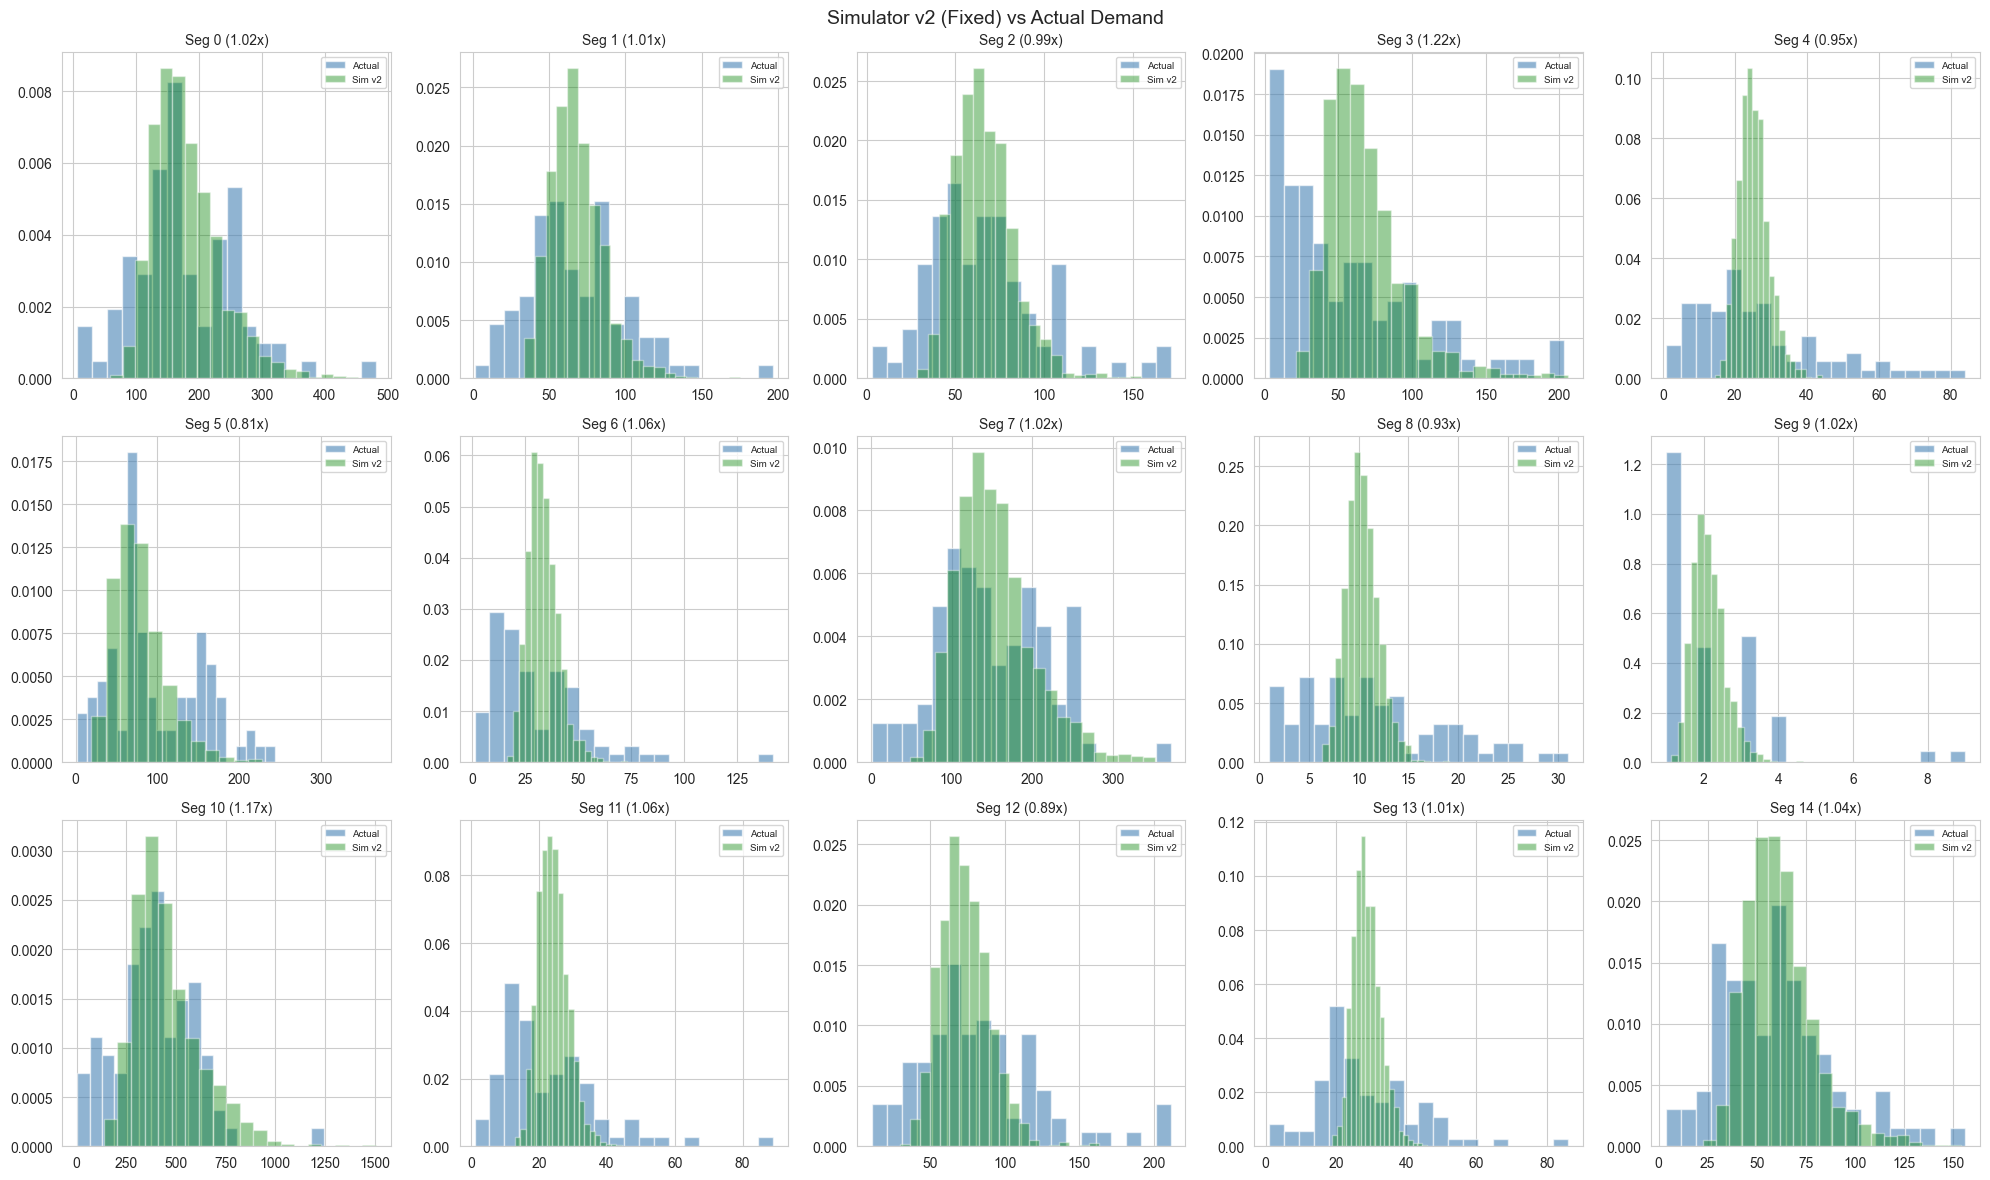

In [12]:
# ══════════════════════════════════════════════════════════════
# Step 7c: Fix review double-counting & final v2 calibration
# ══════════════════════════════════════════════════════════════
# 
# The review modifier was DOUBLE counting - the base demand already includes
# review effects (it's computed from historical data where reviews already
# influenced outcomes). Reviews should only matter RELATIVE to the base,
# e.g., if reviews change or as a cross-segment selection signal.
#
# Fix: Remove the static review modifier. Instead, use reviews as a 
# "quality floor" that prevents demand from falling below a minimum
# when promotions are aggressive (low-quality products don't benefit 
# as much from deep discounts).

class SimulatorV2Fixed(SimulatorV2):
    def step(self, state, action_selection, action_discounts):
        selection = np.clip(action_selection, 0, 1)
        discounts = np.clip(action_discounts, 0, self.max_discount) * selection
        
        # 1. AR base demand (no review penalty - already in base)
        prev_demand = state['demand']
        ar_base = self.ar_coeffs * prev_demand + (1 - self.ar_coeffs) * self.base_demand
        
        # 2. Price adjustment
        price_ratio = np.maximum(1.0 - discounts, 0.01)
        price_adjustment = np.power(price_ratio, self.price_elasticity)
        
        # 3. Review-modulated discount responsiveness
        # Low-review segments get dampened discount response (quality-discounting interaction)
        # High-quality items benefit more from promotions
        review_factor = np.where(
            discounts > 0,  # Only applies when discounted
            np.clip(self.avg_review / 4.0, 0.5, 1.2),  # review=4→1.0, review=2→0.5, review=5→1.2
            1.0  # No effect when not discounted
        )
        # Reduce the price adjustment magnitude for low-review segments
        price_adjustment = 1.0 + (price_adjustment - 1.0) * review_factor
        
        # 4. Noise
        noise = np.exp(self.rng.normal(self.resid_mean, self.resid_std))
        
        demand = ar_base * price_adjustment * noise
        demand = np.maximum(demand, 0)
        
        # Budget logic
        step_cost = demand * discounts * self.base_price
        total_cost = step_cost.sum()
        
        if total_cost > state['budget_remaining'] and total_cost > 0:
            scale = state['budget_remaining'] / total_cost
            discounts *= scale
            step_cost *= scale
            price_ratio = np.maximum(1.0 - discounts, 0.01)
            price_adjustment = np.power(price_ratio, self.price_elasticity)
            review_factor = np.where(
                discounts > 0,
                np.clip(self.avg_review / 4.0, 0.5, 1.2),
                1.0
            )
            price_adjustment = 1.0 + (price_adjustment - 1.0) * review_factor
            demand = ar_base * price_adjustment * noise
            demand = np.maximum(demand, 0)
            total_cost = state['budget_remaining']
        
        revenue = (demand * self.base_price * (1.0 - discounts)).sum()
        new_budget = max(0, state['budget_remaining'] - total_cost)
        new_time = state['time_remaining'] - 1
        done = new_time <= 0 or new_budget <= 0
        self.demand_history = demand.copy()
        
        next_state = {
            'selection': selection, 'discounts': discounts,
            'demand': demand, 'budget_consumed': state['budget_consumed'] + step_cost,
            'budget_remaining': new_budget, 'time_remaining': new_time,
        }
        info = {'revenue': revenue, 'step_cost': total_cost,
                'demand': demand.copy(), 'price_adjustment': price_adjustment.copy()}
        return next_state, revenue, done, info

# Validate fixed version
sim_v2f = SimulatorV2Fixed(seed=42)
sim_v2f_demands = {seg: [] for seg in range(15)}
for ep in range(200):
    state = sim_v2f.reset()
    while state['time_remaining'] > 0:
        sel = np.random.binomial(1, 0.3, 15).astype(np.float64)
        disc = np.random.uniform(0.05, 0.20, 15)
        state, _, done, info = sim_v2f.step(state, sel, disc)
        for s in range(15):
            sim_v2f_demands[s].append(info['demand'][s])
        if done:
            break

v2f_stats = []
for seg in range(15):
    d = np.array(sim_v2f_demands[seg])
    v2f_stats.append({'segment': seg, 'sim_v2f_mean': d.mean(), 'sim_v2f_std': d.std()})
v2f_stats = pd.DataFrame(v2f_stats)

comp_v2f = actual_weekly.merge(v2f_stats, on='segment')
comp_v2f['v2f_ratio'] = comp_v2f['sim_v2f_mean'] / comp_v2f['actual_mean']

v2f_corr = np.corrcoef(comp_v2f['actual_mean'], comp_v2f['sim_v2f_mean'])[0, 1]
v2f_mape = np.mean(np.abs(comp_v2f['v2f_ratio'] - 1)) * 100

# KS tests
ks_pass_v2f = 0
for seg in range(15):
    actual = panel[panel['segment'] == seg]['quantity'].values
    simulated = np.array(sim_v2f_demands[seg])
    _, p = sp_stats.ks_2samp(actual, simulated)
    if p > 0.05: ks_pass_v2f += 1

print("═══ SIMULATOR V2 (FIXED) VALIDATION ═══")
print(f"Correlation: {v2f_corr:.4f}  (v1: {v1_corr:.4f}, v2: {v2_corr:.4f})")
print(f"MAPE:        {v2f_mape:.1f}%  (v1: 85.4%, v2: {v2_mape:.1f}%)")
print(f"KS-pass:     {ks_pass_v2f}/15 (v1: 0/15, v2: {ks_pass_v2}/15)")
print(f"\nPer-segment demand ratios (sim/actual):")
for _, r in comp_v2f.iterrows():
    flag = "✓" if abs(r['v2f_ratio'] - 1) < 0.25 else "⚠️"
    print(f"  Seg {int(r['segment']):>2}: {r['v2f_ratio']:.2f}x  {flag}")

# Distribution comparison plot
fig, axes = plt.subplots(3, 5, figsize=(20, 12))
axes = axes.flatten()
for seg in range(15):
    ax = axes[seg]
    actual = panel[panel['segment'] == seg]['quantity'].values
    simulated = np.array(sim_v2f_demands[seg])
    ax.hist(actual, bins=20, alpha=0.6, density=True, label='Actual', color='steelblue')
    ax.hist(simulated, bins=20, alpha=0.4, density=True, label='Sim v2', color='green')
    ratio = comp_v2f[comp_v2f['segment']==seg]['v2f_ratio'].values[0]
    ax.set_title(f'Seg {seg} ({ratio:.2f}x)', fontsize=10)
    ax.legend(fontsize=7)
plt.suptitle('Simulator v2 (Fixed) vs Actual Demand', fontsize=14)
plt.tight_layout()
plt.savefig(DATA_DIR + 'fig_v2f_distributions.png', dpi=150, bbox_inches='tight')
plt.show()